In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Soal Latihan pertemuan 13.csv')

print("===== DATA AWAL =====")
print(df)

===== DATA AWAL =====
    ID  Usia  JamBelajar  Kehadiran  Tugas  NilaiUjian Ekstrakurikuler  \
0    1    18           1         60     55          50           Tidak   
1    2    19           2         65     60          55              Ya   
2    3    18           2         70     62          58           Tidak   
3    4    20           3         72     65          60              Ya   
4    5    19           3         75     68          65           Tidak   
5    6    21           4         78     70          70              Ya   
6    7    20           4         80     72          72              Ya   
7    8    22           5         85     75          78              Ya   
8    9    18           1         62     56          52           Tidak   
9   10    19           2         68     61          57              Ya   
10  11    20           3         74     66          64           Tidak   
11  12    21           4         79     71          73              Ya   
12  13    22    

In [ ]:
print("\n===== INFO DATASET =====")
print(df.info())


===== INFO DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               30 non-null     int64 
 1   Usia             30 non-null     int64 
 2   JamBelajar       30 non-null     int64 
 3   Kehadiran        30 non-null     int64 
 4   Tugas            30 non-null     int64 
 5   NilaiUjian       30 non-null     int64 
 6   Ekstrakurikuler  30 non-null     object
 7   StatusEkonomi    30 non-null     object
 8   Lulus            30 non-null     object
dtypes: int64(6), object(3)
memory usage: 2.2+ KB
None


In [ ]:
print("\n===== STATISTIK DATA =====")
print(df.describe())


===== STATISTIK DATA =====
              ID       Usia  JamBelajar  Kehadiran     Tugas  NilaiUjian
count  30.000000  30.000000   30.000000  30.000000  30.00000   30.000000
mean   15.500000  19.866667    2.966667  73.533333  66.00000   65.266667
std     8.803408   1.382984    1.351457   9.065788   7.91768   11.711866
min     1.000000  18.000000    1.000000  60.000000  54.00000   49.000000
25%     8.250000  19.000000    2.000000  66.250000  60.00000   56.250000
50%    15.500000  20.000000    3.000000  73.500000  65.50000   63.500000
75%    22.750000  21.000000    4.000000  79.750000  71.75000   72.750000
max    30.000000  22.000000    5.000000  90.000000  81.00000   90.000000


In [ ]:
df['Ekstrakurikuler'] = df['Ekstrakurikuler'].map({
    'Tidak':0,
    'Ya':1
})

In [ ]:
df['StatusEkonomi'] = df['StatusEkonomi'].map({
    'Rendah':0,
    'Menengah':1,
    'Tinggi':2

 })

In [ ]:
df['Lulus'] = df['Lulus'].map({
    'Tidak':0,
    'Ya':1
})

print("\n===== HASIL ENCODING =====")
print(df)


===== HASIL ENCODING =====
    ID  Usia  JamBelajar  Kehadiran  Tugas  NilaiUjian  Ekstrakurikuler  \
0    1    18           1         60     55          50                0   
1    2    19           2         65     60          55                1   
2    3    18           2         70     62          58                0   
3    4    20           3         72     65          60                1   
4    5    19           3         75     68          65                0   
5    6    21           4         78     70          70                1   
6    7    20           4         80     72          72                1   
7    8    22           5         85     75          78                1   
8    9    18           1         62     56          52                0   
9   10    19           2         68     61          57                1   
10  11    20           3         74     66          64                0   
11  12    21           4         79     71          73                1 

In [ ]:
scaler = MinMaxScaler()

kolom_scaling = [
    'Usia',
    'JamBelajar',
    'Kehadiran',
    'Tugas',
    'NilaiUjian'
]

df[kolom_scaling] = scaler.fit_transform(df[kolom_scaling])

print("\n===== HASIL SCALING =====")
print(df)


===== HASIL SCALING =====
    ID  Usia  JamBelajar  Kehadiran     Tugas  NilaiUjian  Ekstrakurikuler  \
0    1  0.00        0.00   0.000000  0.037037    0.024390                0   
1    2  0.25        0.25   0.166667  0.222222    0.146341                1   
2    3  0.00        0.25   0.333333  0.296296    0.219512                0   
3    4  0.50        0.50   0.400000  0.407407    0.268293                1   
4    5  0.25        0.50   0.500000  0.518519    0.390244                0   
5    6  0.75        0.75   0.600000  0.592593    0.512195                1   
6    7  0.50        0.75   0.666667  0.666667    0.560976                1   
7    8  1.00        1.00   0.833333  0.777778    0.707317                1   
8    9  0.00        0.00   0.066667  0.074074    0.073171                0   
9   10  0.25        0.25   0.266667  0.259259    0.195122                1   
10  11  0.50        0.50   0.466667  0.444444    0.365854                0   
11  12  0.75        0.75   0.633333  

In [ ]:
df['RataNilai'] = (
    df['Tugas'] +
    df['NilaiUjian']
) / 2

# Membuat fitur produktivitas

df['Produktivitas'] = (
    df['JamBelajar'] *
    df['Kehadiran']
)

print("\n===== HASIL FEATURE ENGINEERING =====")
print(df)


===== HASIL FEATURE ENGINEERING =====
    ID  Usia  JamBelajar  Kehadiran     Tugas  NilaiUjian  Ekstrakurikuler  \
0    1  0.00        0.00   0.000000  0.037037    0.024390                0   
1    2  0.25        0.25   0.166667  0.222222    0.146341                1   
2    3  0.00        0.25   0.333333  0.296296    0.219512                0   
3    4  0.50        0.50   0.400000  0.407407    0.268293                1   
4    5  0.25        0.50   0.500000  0.518519    0.390244                0   
5    6  0.75        0.75   0.600000  0.592593    0.512195                1   
6    7  0.50        0.75   0.666667  0.666667    0.560976                1   
7    8  1.00        1.00   0.833333  0.777778    0.707317                1   
8    9  0.00        0.00   0.066667  0.074074    0.073171                0   
9   10  0.25        0.25   0.266667  0.259259    0.195122                1   
10  11  0.50        0.50   0.466667  0.444444    0.365854                0   
11  12  0.75        0.75 

In [ ]:
df_korelasi = df.drop(columns=['ID'])

In [ ]:
korelasi = df_korelasi.corr()

print("\n===== MATRIKS KORELASI =====")
print(korelasi)

print("\n===== KORELASI TERHADAP LULUS =====")
print(korelasi['Lulus'].sort_values(ascending=False))


===== MATRIKS KORELASI =====
                     Usia  JamBelajar  Kehadiran     Tugas  NilaiUjian  \
Usia             1.000000    0.975359   0.943718  0.941582    0.945381   
JamBelajar       0.975359    1.000000   0.978117  0.976437    0.965692   
Kehadiran        0.943718    0.978117   1.000000  0.996339    0.989150   
Tugas            0.941582    0.976437   0.996339  1.000000    0.990260   
NilaiUjian       0.945381    0.965692   0.989150  0.990260    1.000000   
Ekstrakurikuler  0.670537    0.645213   0.598474  0.611836    0.592075   
StatusEkonomi    0.888285    0.919522   0.874007  0.873506    0.841834   
Lulus            0.827810    0.831934   0.838192  0.838184    0.844321   
RataNilai        0.945762    0.973508   0.995218  0.997626    0.997498   
Produktivitas    0.932491    0.944746   0.960574  0.963635    0.980590   

                 Ekstrakurikuler  StatusEkonomi     Lulus  RataNilai  \
Usia                    0.670537       0.888285  0.827810   0.945762   
JamBelajar 

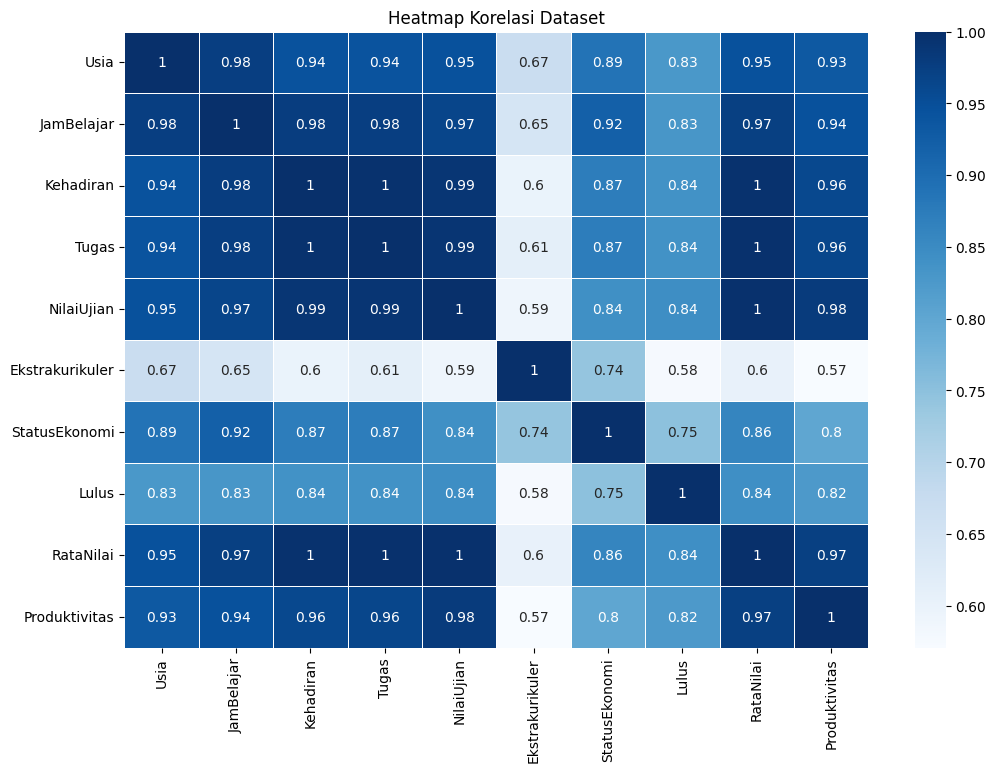

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    korelasi,
    annot=True,
    cmap='Blues',
    linewidths=0.5
)

plt.title("Heatmap Korelasi Dataset")
plt.show()

In [ ]:
print("\n===== DATA SETELAH PREPROCESSING =====")
print(df)


===== DATA SETELAH PREPROCESSING =====
    ID  Usia  JamBelajar  Kehadiran     Tugas  NilaiUjian  Ekstrakurikuler  \
0    1  0.00        0.00   0.000000  0.037037    0.024390                0   
1    2  0.25        0.25   0.166667  0.222222    0.146341                1   
2    3  0.00        0.25   0.333333  0.296296    0.219512                0   
3    4  0.50        0.50   0.400000  0.407407    0.268293                1   
4    5  0.25        0.50   0.500000  0.518519    0.390244                0   
5    6  0.75        0.75   0.600000  0.592593    0.512195                1   
6    7  0.50        0.75   0.666667  0.666667    0.560976                1   
7    8  1.00        1.00   0.833333  0.777778    0.707317                1   
8    9  0.00        0.00   0.066667  0.074074    0.073171                0   
9   10  0.25        0.25   0.266667  0.259259    0.195122                1   
10  11  0.50        0.50   0.466667  0.444444    0.365854                0   
11  12  0.75        0.75

In [ ]:
df.to_csv("dataset_preprocessing.csv", index=False)

print("\nData berhasil disimpan dengan nama dataset_preprocessing.csv")


Data berhasil disimpan dengan nama dataset_preprocessing.csv
